In [3]:
import pandas as pd
df = pd.DataFrame (
    {"Name": ["Braund, Mr. Owen Harris", "Amy", "Brian"],
    "Age": [23,20,21],
    "Sex": [ "male", "male", "female"]
    })
print(df)

df["Name"]
df["Age"].max()
df.describe()
type(df["Name"])
df.shape
df["Age"]> 1


                      Name  Age     Sex
0  Braund, Mr. Owen Harris   23    male
1                      Amy   20    male
2                    Brian   21  female


0    True
1    True
2    True
Name: Age, dtype: bool

<function matplotlib.pyplot.show(close=None, block=None)>

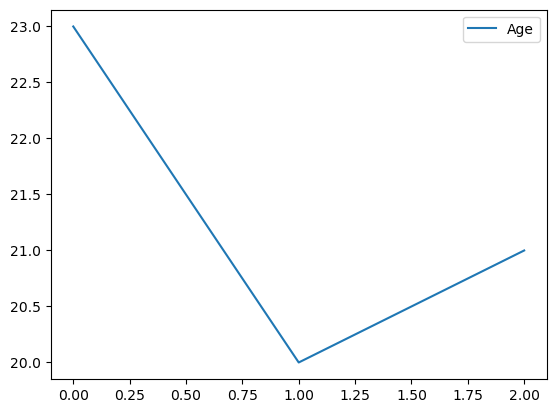

In [4]:
import matplotlib.pyplot as plt
df.plot()
plt.show

In [5]:
titanic = pd.read_csv("/home/fgsasse_lrs_1/Downloads/pandas_ex/titanic.csv")
air_quality = pd.read_csv("/home/fgsasse_lrs_1/Downloads/pandas_ex/air_quality_long.csv", index_col = "date.utc", parse_dates = True)

titanic.head()
titanic.sort_values("Age", ascending=False)

air_quality.head()  
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


<Axes: xlabel='date.utc'>

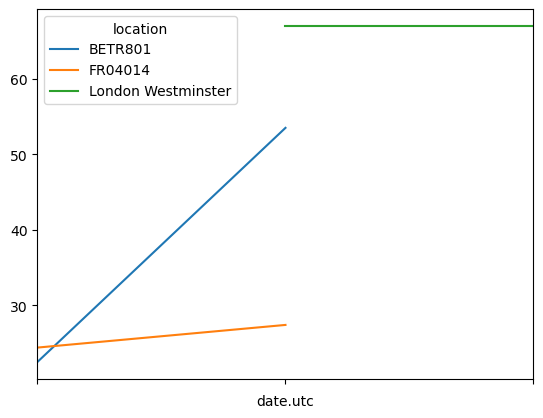

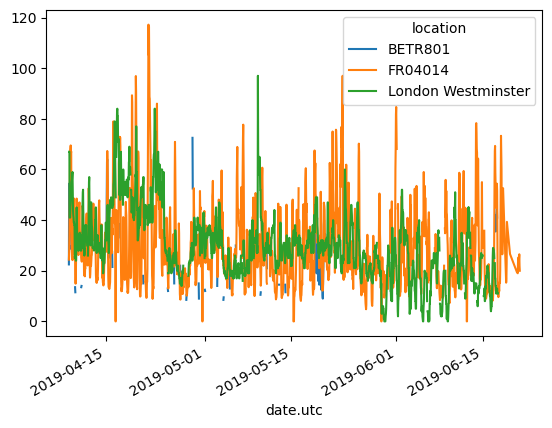

In [18]:
no2 = air_quality[air_quality["parameter"] == "no2"]
no2_subset = no2.sort_index(). groupby("location").head(2)


no2_subset.pivot(columns = "location", values = "value").plot() 
no2.pivot(columns = "location", values = "value").plot()


In [55]:
no2_pivot = no2.pivot(columns = "location", values = "value") 
print(no2_pivot)
no2_sum = no2.pivot_table(index= "location", columns= "parameter", values="value", aggfunc="mean")
print(no2_sum)
no2_pivoted = no2_pivot.reset_index()
no2_pivoted2 = no2_pivoted.melt(id_vars = "date.utc", value_name="no2")
print(no2_pivoted2)


location                   BETR801  FR04014  London Westminster
date.utc                                                       
2019-04-09 01:00:00+00:00     22.5     24.4                 NaN
2019-04-09 02:00:00+00:00     53.5     27.4                67.0
2019-04-09 03:00:00+00:00     54.5     34.2                67.0
2019-04-09 04:00:00+00:00     34.5     48.5                41.0
2019-04-09 05:00:00+00:00     46.5     59.5                41.0
...                            ...      ...                 ...
2019-06-20 20:00:00+00:00      NaN     21.4                 NaN
2019-06-20 21:00:00+00:00      NaN     24.9                 NaN
2019-06-20 22:00:00+00:00      NaN     26.5                 NaN
2019-06-20 23:00:00+00:00      NaN     21.8                 NaN
2019-06-21 00:00:00+00:00      NaN     20.0                 NaN

[1705 rows x 3 columns]
parameter                 no2
location                     
BETR801             26.950920
FR04014             29.374284
London Westminster  29.

In [79]:
aqno2 = pd.read_csv("/home/fgsasse_lrs_1/Downloads/pandas_ex/air_quality_no2_long.csv")  
aqpm25 = pd.read_csv("/home/fgsasse_lrs_1/Downloads/pandas_ex/air_quality_pm25_long.csv")

display(aqno2.head(5))
display(aqpm25.head(5))

aq = pd.concat([aqno2, aqpm25], axis=0)

print(aqno2.shape[0] + aqpm25.shape[0] == aq.shape[0])
print(aqno2.shape)
print(aqpm25.shape)
print(aq.shape)

aq.sort_values("date.utc").head(5)

,city,country,date.utc,location,parameter,value,unit
0,Paris,FR,2019-06-21 00:00:00+00:00,FR04014,no2,20.0,µg/m³
1,Paris,FR,2019-06-20 23:00:00+00:00,FR04014,no2,21.8,µg/m³
2,Paris,FR,2019-06-20 22:00:00+00:00,FR04014,no2,26.5,µg/m³
3,Paris,FR,2019-06-20 21:00:00+00:00,FR04014,no2,24.9,µg/m³
4,Paris,FR,2019-06-20 20:00:00+00:00,FR04014,no2,21.4,µg/m³


,city,country,date.utc,location,parameter,value,unit
0,Antwerpen,BE,2019-06-18 06:00:00+00:00,BETR801,pm25,18.0,µg/m³
1,Antwerpen,BE,2019-06-17 08:00:00+00:00,BETR801,pm25,6.5,µg/m³
2,Antwerpen,BE,2019-06-17 07:00:00+00:00,BETR801,pm25,18.5,µg/m³
3,Antwerpen,BE,2019-06-17 06:00:00+00:00,BETR801,pm25,16.0,µg/m³
4,Antwerpen,BE,2019-06-17 05:00:00+00:00,BETR801,pm25,7.5,µg/m³


True
(2068, 7)
(1110, 7)
(3178, 7)


,city,country,date.utc,location,parameter,value,unit
1109,London,GB,2019-05-07 01:00:00+00:00,London Westminster,pm25,8.0,µg/m³
2067,London,GB,2019-05-07 01:00:00+00:00,London Westminster,no2,23.0,µg/m³
1098,Antwerpen,BE,2019-05-07 01:00:00+00:00,BETR801,no2,50.5,µg/m³
1003,Paris,FR,2019-05-07 01:00:00+00:00,FR04014,no2,25.0,µg/m³
100,Antwerpen,BE,2019-05-07 01:00:00+00:00,BETR801,pm25,12.5,µg/m³


In [103]:
air_quality = pd.read_csv("/home/fgsasse_lrs_1/Downloads/pandas_ex/air_quality_no2_long.csv") #parse_dates = "datetime
air_quality.columns.unique()    

air_quality["datetime"] = pd.to_datetime(air_quality["date.utc"])
air_quality["datetime"].min(), air_quality["datetime"].max() 
air_quality["datetime"].max() - air_quality["datetime"].min()

air_quality["year"] = air_quality["datetime"].dt.year
display(air_quality.head(5))

air_quality.groupby([air_quality["datetime"].dt.weekday, "location"])["value"].mean()
display(air_quality.head(5))

,city,country,date.utc,location,parameter,value,unit,datetime,year
0,Paris,FR,2019-06-21 00:00:00+00:00,FR04014,no2,20.0,µg/m³,2019-06-21 00:00:00+00:00,2019
1,Paris,FR,2019-06-20 23:00:00+00:00,FR04014,no2,21.8,µg/m³,2019-06-20 23:00:00+00:00,2019
2,Paris,FR,2019-06-20 22:00:00+00:00,FR04014,no2,26.5,µg/m³,2019-06-20 22:00:00+00:00,2019
3,Paris,FR,2019-06-20 21:00:00+00:00,FR04014,no2,24.9,µg/m³,2019-06-20 21:00:00+00:00,2019
4,Paris,FR,2019-06-20 20:00:00+00:00,FR04014,no2,21.4,µg/m³,2019-06-20 20:00:00+00:00,2019


,city,country,date.utc,location,parameter,value,unit,datetime,year
0,Paris,FR,2019-06-21 00:00:00+00:00,FR04014,no2,20.0,µg/m³,2019-06-21 00:00:00+00:00,2019
1,Paris,FR,2019-06-20 23:00:00+00:00,FR04014,no2,21.8,µg/m³,2019-06-20 23:00:00+00:00,2019
2,Paris,FR,2019-06-20 22:00:00+00:00,FR04014,no2,26.5,µg/m³,2019-06-20 22:00:00+00:00,2019
3,Paris,FR,2019-06-20 21:00:00+00:00,FR04014,no2,24.9,µg/m³,2019-06-20 21:00:00+00:00,2019
4,Paris,FR,2019-06-20 20:00:00+00:00,FR04014,no2,21.4,µg/m³,2019-06-20 20:00:00+00:00,2019


In [107]:
titanic[titanic["Name"].str.contains("Braund")]


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
477,478,0,3,"Braund, Mr. Lewis Richard",male,29.0,1,0,3460,7.0458,NaN,S
